<a href="https://colab.research.google.com/github/kundankumar09-v/weekly_assignments_CEI/blob/main/week3_kundan_kumar_vennaboina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Loading and Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 2. Dataset Overview

In [2]:
df = pd.read_csv('/content/Country-data.csv')

# 3. Exploratory Data Analysis

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# 4. Data Preprocessing and Scaling

In [4]:
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nData Types:")
print(df.dtypes)

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Rows: 0

Data Types:
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object


# 5. Elbow Method for Optimal K

In [5]:
country_names = df['country']
X = df.drop('country', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Silhouette Score Analysis

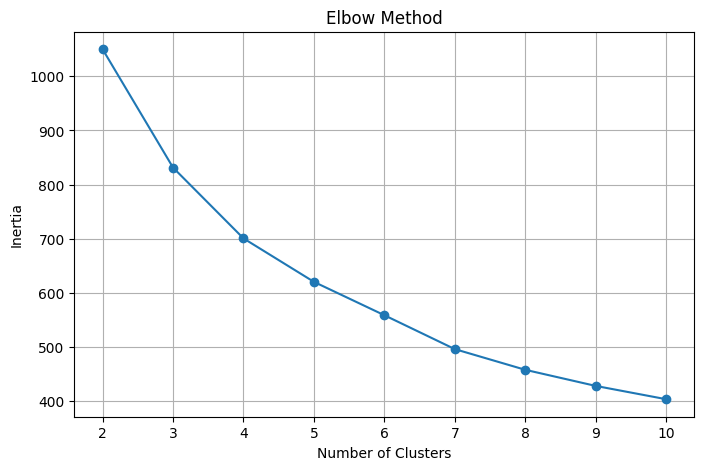

In [6]:
inertia = []
for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

# 7. KMeans Model Training

In [7]:
scores = []
for k in range(2,11):
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,labels)
    scores.append(score)
    print(f'K={k}, Silhouette={score:.4f}')

K=2, Silhouette=0.2874
K=3, Silhouette=0.2833
K=4, Silhouette=0.2960
K=5, Silhouette=0.2993
K=6, Silhouette=0.2287
K=7, Silhouette=0.2477
K=8, Silhouette=0.2388
K=9, Silhouette=0.2073
K=10, Silhouette=0.2022


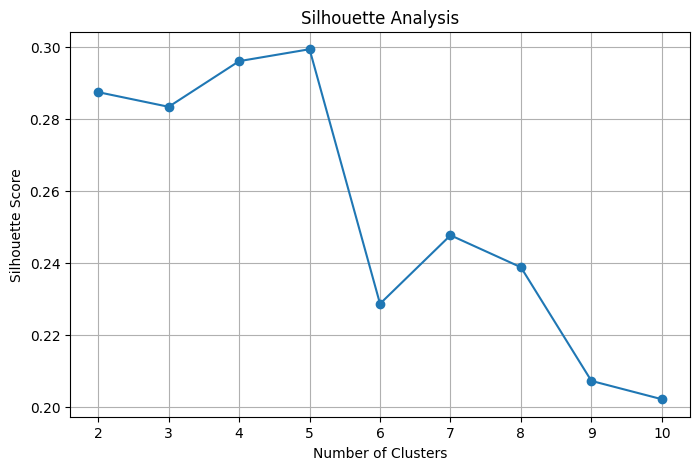

In [8]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11),scores,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True)
plt.show()

# 8. Cluster Distribution

In [9]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

# 9. Cluster Profiling

In [10]:
print(df['Cluster'].value_counts())

Cluster
2    84
1    47
0    36
Name: count, dtype: int64


In [11]:
final_score = silhouette_score(X_scaled,cluster_labels)
print("Final Silhouette Score:", final_score)

Final Silhouette Score: 0.28329575683463126


# 10. Visualization of Average Features

In [12]:
print("KMeans Evaluation")
print("-"*30)
print("Number of Clusters:", len(set(cluster_labels)))
print("Silhouette Score:", round(final_score,4))

KMeans Evaluation
------------------------------
Number of Clusters: 3
Silhouette Score: 0.2833


In [13]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [14]:
cluster_profile[['child_mort','income','life_expec','gdpp']]

,child_mort,income,life_expec,gdpp
Cluster,,,,
0,5.000000,45672.222222,80.127778,42494.444444
1,92.961702,3942.404255,59.187234,1922.382979
2,21.927381,12305.595238,72.814286,6486.452381


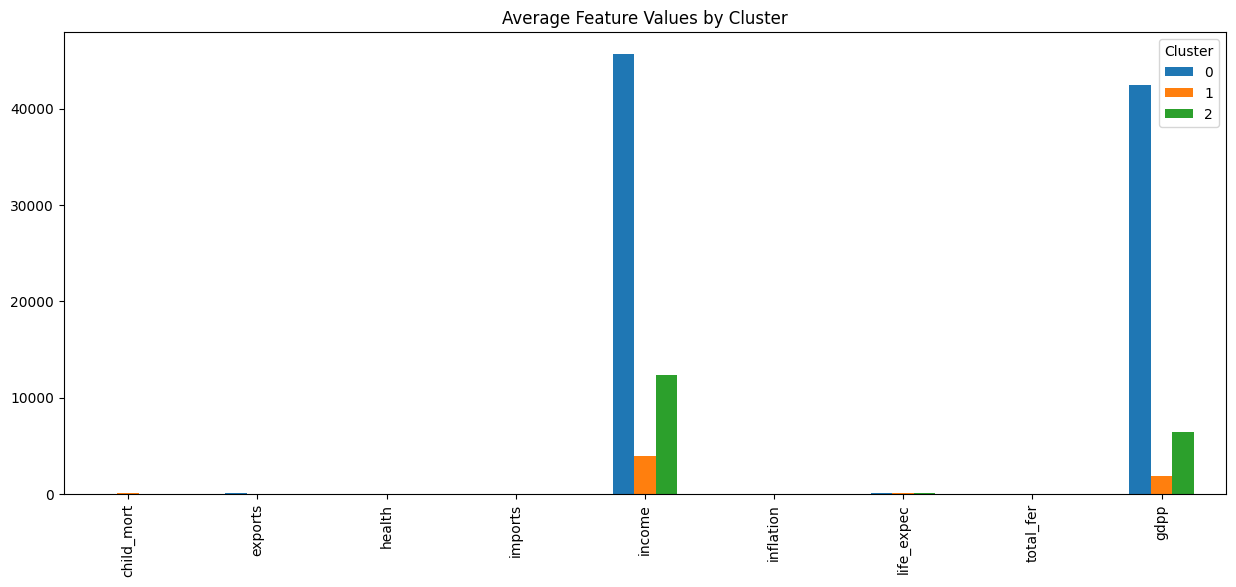

In [15]:
cluster_profile.T.plot(kind='bar',figsize=(15,6))
plt.title('Average Feature Values by Cluster')
plt.show()

# 11. Density-Based Clustering (DBSCAN)

In [16]:
dbscan = DBSCAN(eps=1.5,min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = db_labels

In [17]:
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


# 12. PCA Dimensionality Reduction

In [18]:
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print("DBSCAN Clusters:", n_clusters)
print("Noise Points:", n_noise)

DBSCAN Clusters: 1
Noise Points: 30


### 11.5 Algorithm Comparison: KMeans vs DBSCAN

KMeans Silhouette Score: 0.2833
DBSCAN Silhouette Score: 0.2883


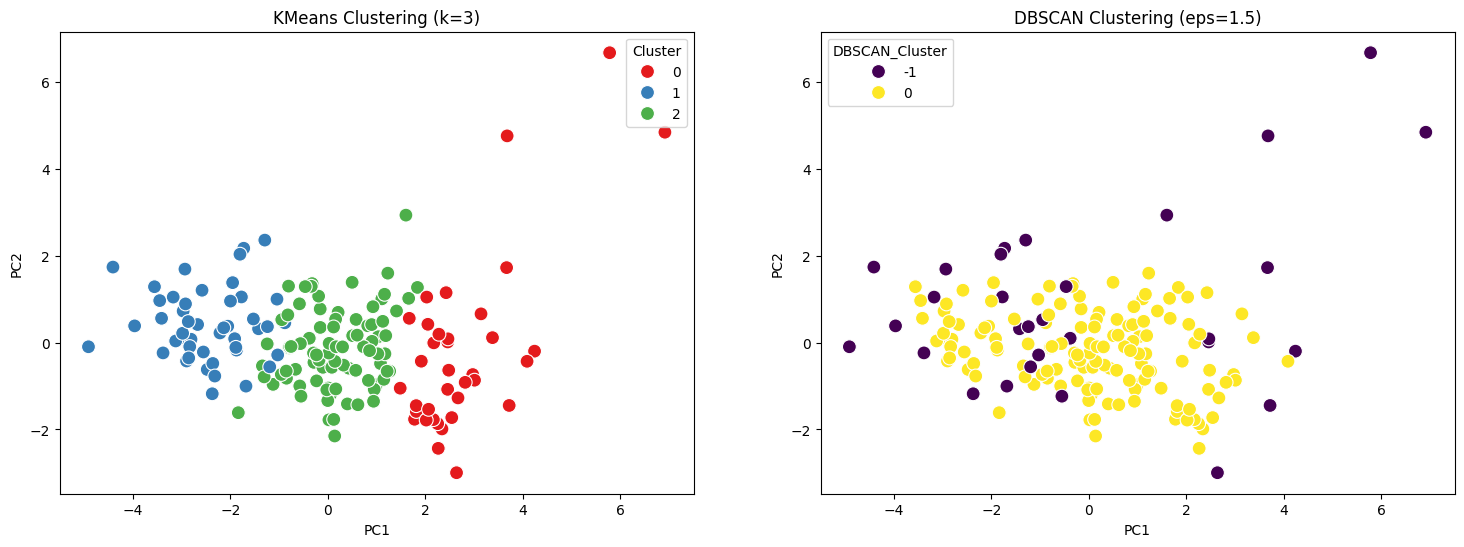

In [19]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels
pca_df['DBSCAN_Cluster'] = db_labels

km_sil = silhouette_score(X_scaled, cluster_labels)
db_sil = silhouette_score(X_scaled, db_labels) if len(set(db_labels)) > 1 else "N/A"

print(f"KMeans Silhouette Score: {km_sil:.4f}")
print(f"DBSCAN Silhouette Score: {db_sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=100, ax=ax1)
ax1.set_title('KMeans Clustering (k=3)')
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='DBSCAN_Cluster', palette='viridis', s=100, ax=ax2)
ax2.set_title('DBSCAN Clustering (eps=1.5)')
plt.show()

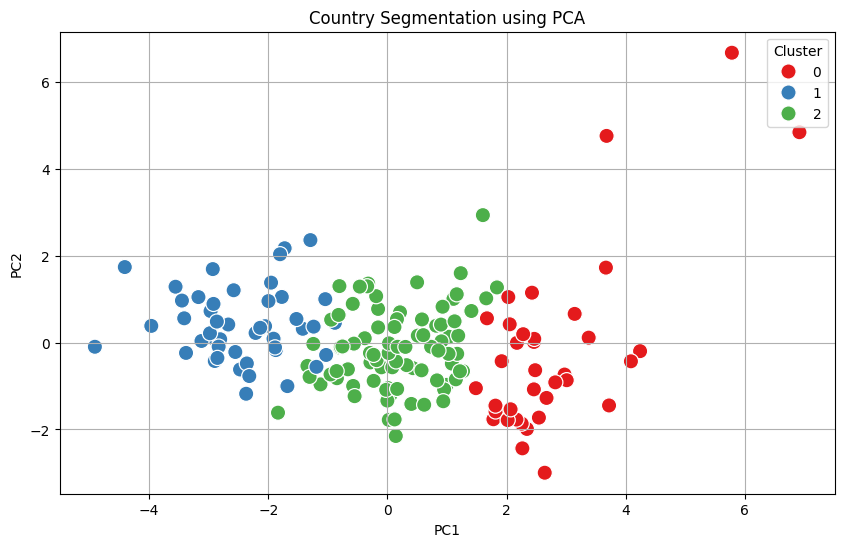

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=pca_df,x='PC1',y='PC2',hue='Cluster',palette='Set1',s=120)
plt.title('Country Segmentation using PCA')
plt.grid(True)
plt.show()

# 13. PCA Cluster Visualization

# 14. Distribution Analysis and Correlations

/tmp/ipykernel_25772/3804342556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='viridis')
/tmp/ipykernel_25772/3804342556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='viridis')
/tmp/ipykernel_25772/3804342556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='viridis')
/tmp/ipykernel_25772/3804342556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign t

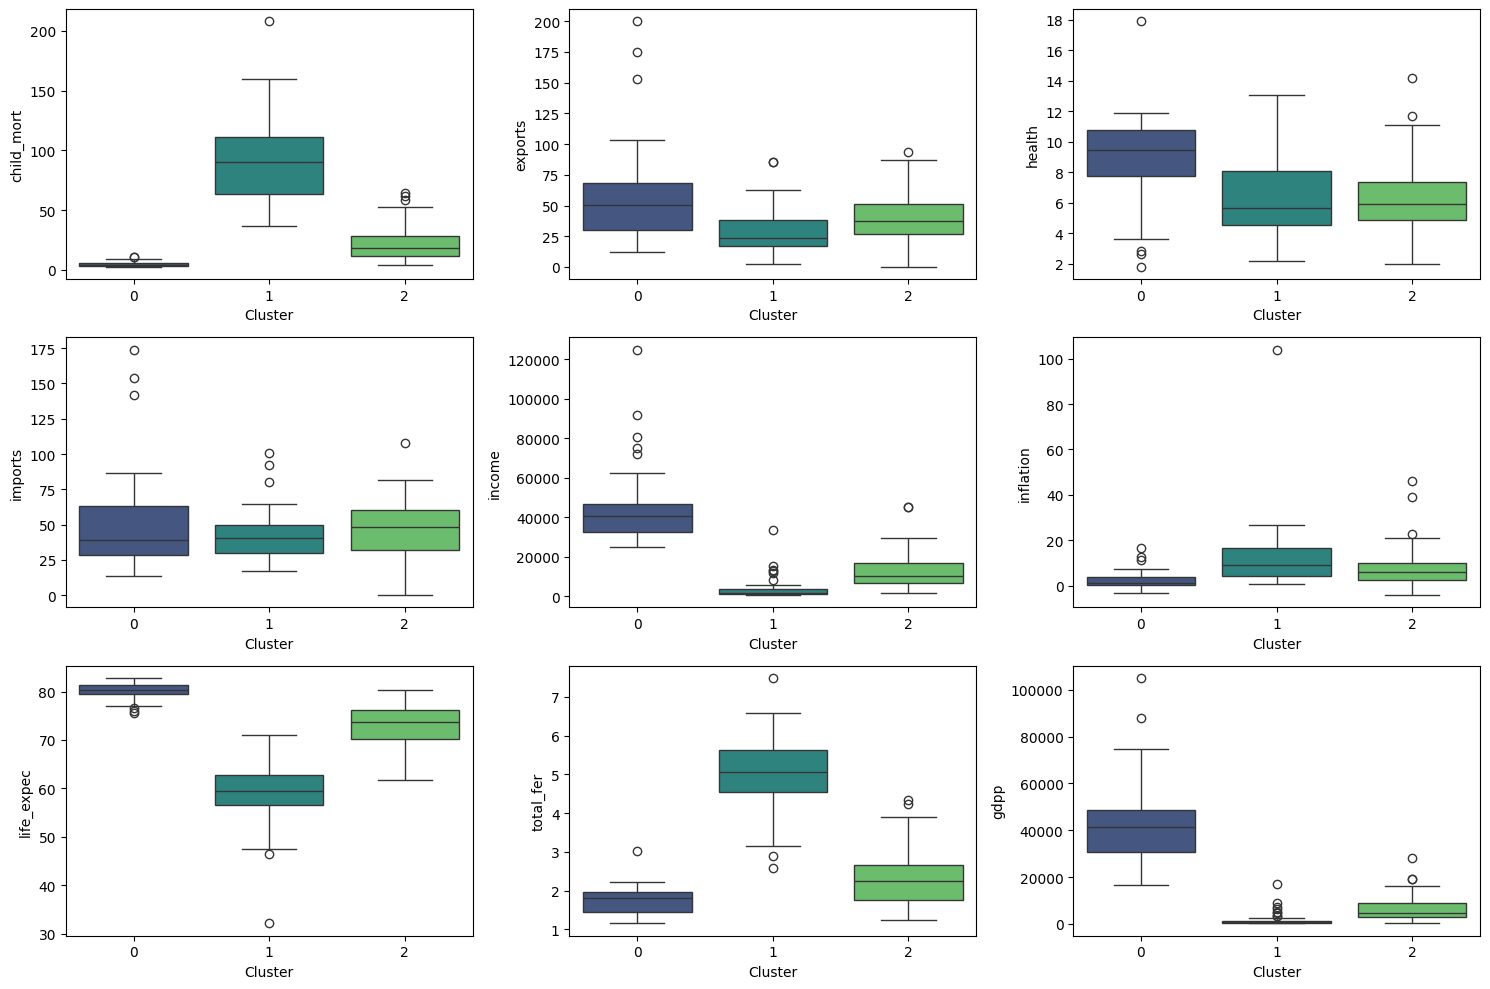

In [21]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(X.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='Cluster', y=col, data=df, palette='viridis')
plt.tight_layout()
plt.show()

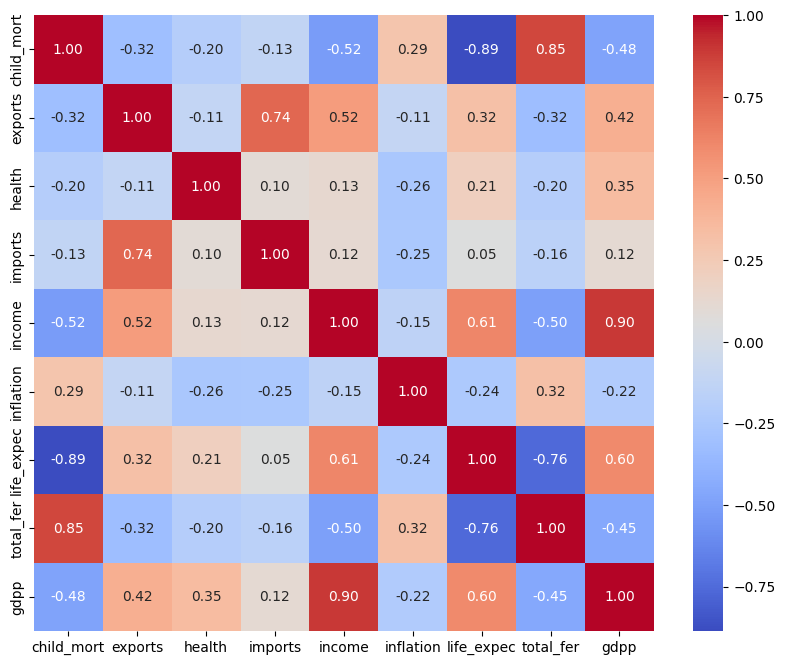

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [23]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Total Variance Captured:",round(sum(pca.explained_variance_ratio_)*100,2),"%")

Explained Variance Ratio:
[0.4595174  0.17181626]
Total Variance Captured: 63.13 %


In [24]:
for cluster in sorted(df['Cluster'].unique()):
    print("\n" + "="*60)
    print(f"Cluster {cluster}")
    print("="*60)
    print(df[df['Cluster']==cluster]['country'].values)


Cluster 0
['Australia' 'Austria' 'Bahrain' 'Belgium' 'Brunei' 'Canada' 'Cyprus'
 'Czech Republic' 'Denmark' 'Finland' 'France' 'Germany' 'Greece'
 'Iceland' 'Ireland' 'Israel' 'Italy' 'Japan' 'Kuwait' 'Luxembourg'
 'Malta' 'Netherlands' 'New Zealand' 'Norway' 'Portugal' 'Qatar'
 'Singapore' 'Slovak Republic' 'Slovenia' 'South Korea' 'Spain' 'Sweden'
 'Switzerland' 'United Arab Emirates' 'United Kingdom' 'United States']

Cluster 1
['Afghanistan' 'Angola' 'Benin' 'Botswana' 'Burkina Faso' 'Burundi'
 'Cameroon' 'Central African Republic' 'Chad' 'Comoros' 'Congo, Dem. Rep.'
 'Congo, Rep.' "Cote d'Ivoire" 'Equatorial Guinea' 'Eritrea' 'Gabon'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Haiti' 'Iraq' 'Kenya'
 'Kiribati' 'Lao' 'Lesotho' 'Liberia' 'Madagascar' 'Malawi' 'Mali'
 'Mauritania' 'Mozambique' 'Namibia' 'Niger' 'Nigeria' 'Pakistan' 'Rwanda'
 'Senegal' 'Sierra Leone' 'South Africa' 'Sudan' 'Tanzania' 'Timor-Leste'
 'Togo' 'Uganda' 'Yemen' 'Zambia']

Cluster 2
['Albania' 'Algeria' 'An

In [25]:
aid_countries = df[
    df['Cluster'] == 1
][['country','child_mort','income','gdpp']]
aid_countries.sort_values(by='child_mort',ascending=False).head(10)

,country,child_mort,income,gdpp
66,Haiti,208.0,1500,662
132,Sierra Leone,160.0,1220,399
32,Chad,150.0,1930,897
31,Central African Republic,149.0,888,446
97,Mali,137.0,1870,708
113,Nigeria,130.0,5150,2330
112,Niger,123.0,814,348
3,Angola,119.0,5900,3530
25,Burkina Faso,116.0,1430,575
37,"Congo, Dem. Rep.",116.0,609,334


In [26]:
df.to_csv('country_segmentation_output.csv',index=False)
print("Output saved successfully")

Output saved successfully


### 15. Ensemble Learning for Segment Prediction

In [27]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
X_train, X_test, y_train, y_test = train_test_split(X_scaled, cluster_labels, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest Performance:")
print(classification_report(y_test, rf_preds))
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("\nXGBoost Performance:")
print(classification_report(y_test, xgb_preds))

Random Forest Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34


XGBoost Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



### 16. Feature Importance Analysis

/tmp/ipykernel_25772/3568024362.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')


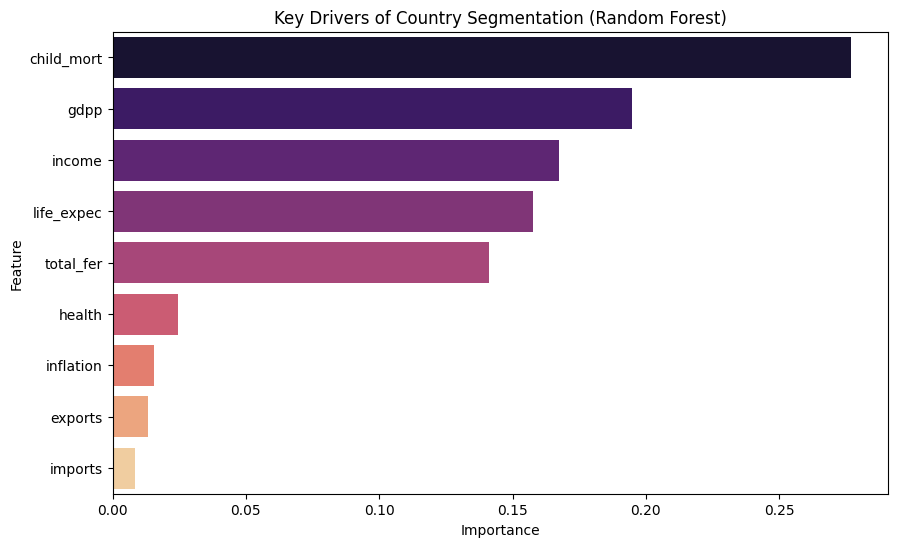

In [28]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')
plt.title('Key Drivers of Country Segmentation (Random Forest)')
plt.show()

### 17. Final Observations

- **Cluster 0 (High Development):** Characterized by high GDPP, high income, and very low child mortality. These are economically stable, developed nations.
- **Cluster 1 (Low Development):** Defined by high child mortality, low income, and low life expectancy. These countries likely require the most targeted international aid.
- **Cluster 2 (Developing):** Mid-range values across most socio-economic indicators. These represent emerging economies with moderate growth and healthcare metrics.
- **Key Drivers:** Feature importance analysis reveals that GDPP, Income, and Child Mortality are the primary factors separating these segments.